#CONTROLE DE ACESSO AO SENAI

Adicionei uma pasta chamada autorizados com diversas fotos de homens e mulheres. Durante o projeto vou realizar 4 testes. 2 com pessoas que não estão nessa pasta e 2 com pessoas que estão nessa pasta. O modelo dever ser capaz de verificar e classificar os atores.

In [1]:
#Importações para o Projeto
!pip install -q deepface opencv-python matplotlib

import cv2
from matplotlib import pyplot as plt
from deepface import DeepFace

# Baixa o classificador Haarcascade para detecção de rostos frontais
!wget -- no-check-certificate \
https://raw.githubusercontent.com/computationalcore/introduction-to-opencv/master/assets/haarcascade_frontalface_default.xml \
-0 haarcascade_frontalface_default.xml

# Baixa um script auxiliar (common.py) com funções de apoio (carregar/exibir imagens, etc.)
!wget -- no-check-certificate \
https://raw.githubusercontent.com/computationalcore/introduction-to-opencv/master/utils/common.py \
-O common.py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.0 MB/s eta 0:00:00
26-04-02 00:23:01 - Directory /root/.deepface has been created
26-04-02 00:23:01 - Directory /root/.deepface/weights has been created
--2026-04-02 00:23:01--  http://no-check-certificate/
Resolving no-check-certificate (no-check-certificate)... failed: Name or service not known.
wget: unable to resolve host address ‘no-check-certificate’
--2026-04-02 00:23:01--  https://raw.githubusercontent.com/computationalcore/introduction-to-opencv/master/a

#Leitura das imagens de teste

In [2]:
#Etapa de adicionar o caminho dos arquivos de imagem
img_test_h = "teste_homem.jpg"
img_test_m = "teste_mulher.jpg"
img_valid_test_h = "teste_valid_homem.jpg"
img_valid_test_m = "teste_valid_mulher.jpg"

#Lê os arquivos usando a função cv2
img_test_h_bgr = cv2.imread(img_test_h)
img_test_m_bgr = cv2.imread(img_test_m)
img_valid_test_h_bgr = cv2.imread(img_valid_test_h)
img_valid_test_m_bgr = cv2.imread(img_valid_test_m)

#Converte imagens para RGB para leitura do OpenCV
img_test_h_rgb = cv2.cvtColor(img_test_h_bgr, cv2.COLOR_BGR2RGB)
img_test_m_rgb = cv2.cvtColor(img_test_m_bgr, cv2.COLOR_BGR2RGB)
img_valid_test_h_rgb = cv2.cvtColor(img_valid_test_h_bgr, cv2.COLOR_BGR2RGB)
img_valid_test_m_rgb = cv2.cvtColor(img_valid_test_m_bgr, cv2.COLOR_BGR2RGB)


#Mostra Imagens na tela

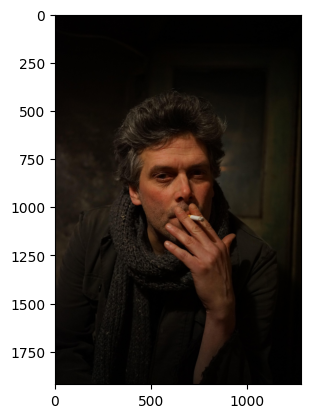

In [3]:
#Ator não autorizado.
plt.imshow(img_test_h_rgb)

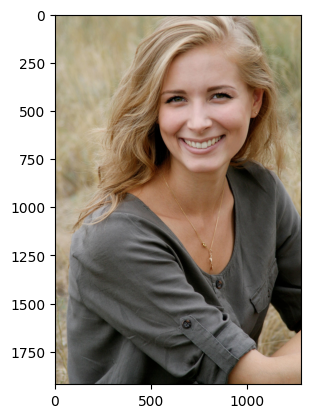

In [4]:
#Atriz não autorizada
plt.imshow(img_test_m_rgb)

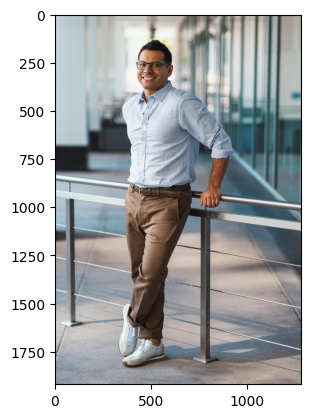

In [5]:
#Ator autorizado
plt.imshow(img_valid_test_h_rgb)

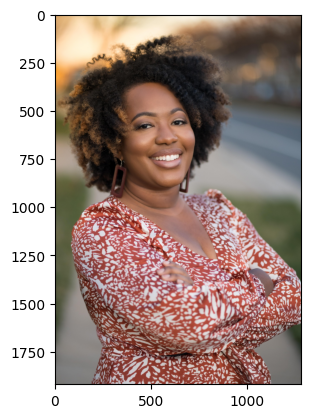

In [6]:
plt.imshow(img_valid_test_m_rgb)

#Início da Comparação Facial

In [11]:
imagens_teste = [img_valid_test_m_rgb, img_valid_test_h_rgb, img_test_h_rgb, img_test_m_rgb]

# DeepFace.find(imagens_teste, db_path = "./autorizados", model_name = 'Facenet')

results = []
for img in imagens_teste:
        result = DeepFace.find(img, db_path = "./autorizados", model_name = 'Facenet', enforce_detection=False)
        results.append(result)

for i, res in enumerate(results):
    print(f"Validação {i+1}:\n{res}\n")

26-04-02 00:59:52 - Searching [[[216 162 102]
  [217 163 103]
  [216 162 102]
  ...
  [132 105  88]
  [132 105  88]
  [133 106  89]]

 [[215 161 101]
  [215 161 101]
  [215 161 101]
  ...
  [130 103  86]
  [130 103  86]
  [131 104  87]]

 [[214 160 100]
  [214 160 100]
  [214 160 100]
  ...
  [129 102  85]
  [129 102  85]
  [129 102  85]]

 ...

 [[117 116 114]
  [118 117 115]
  [118 117 115]
  ...
  [102 104 101]
  [102 104 101]
  [102 104 101]]

 [[118 117 115]
  [118 117 115]
  [118 117 115]
  ...
  [102 104 101]
  [102 104 101]
  [102 104 101]]

 [[118 117 115]
  [118 117 115]
  [118 117 115]
  ...
  [102 104 101]
  [102 104 101]
  [102 104 101]]] in 7 length datastore
26-04-02 00:59:52 - find function duration 2.878944158554077 seconds
26-04-02 00:59:55 - Searching [[[193 208 213]
  [193 208 213]
  [193 208 213]
  ...
  [156 152 141]
  [156 152 141]
  [156 152 141]]

 [[193 208 213]
  [193 208 213]
  [193 208 213]
  ...
  [156 152 141]
  [156 152 141]
  [156 152 141]]

 [[193 208 

#Constatação Inicial

Vaidação 1 e 2 identificaram perfeitamente as pessoas "autorizadas", com foto dentro da pasta ./autorizados. As verificações 3 e 4, representaram os testes não válidos e retornaram vazio, ou seja, acesso proibido.

#Resultado Final

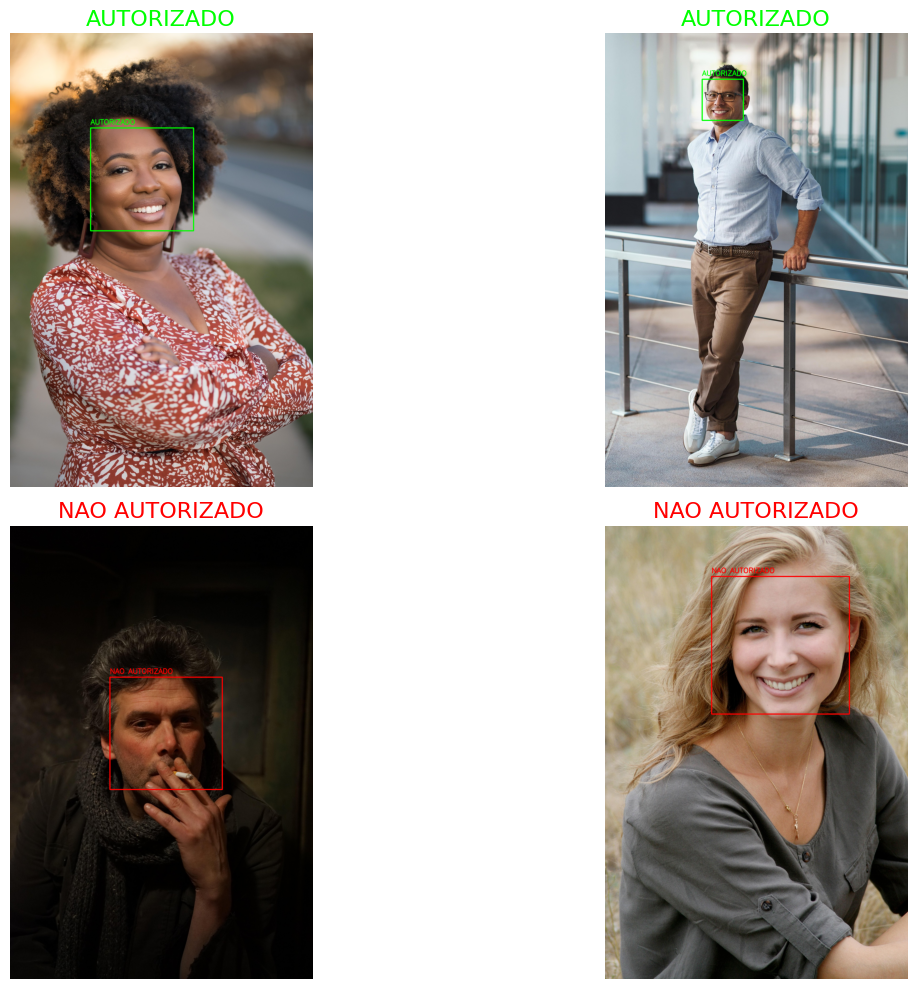

In [20]:
# Cria Base da Imagem e subplots para todas as 4 imagens em um grid 2x2
background, eixos = plt.subplots(2, 2, figsize=(15, 10))
eixos = eixos.flatten()

for i, img_rgb in enumerate(imagens_teste):
    # Cria cópia de segurança
    img_display = img_rgb.copy()

    img_df_list = results[i]

    # Inicia variável das coordenadas
    x, y, w, h = 0, 0, 0, 0
    face_was_detected = False

    # Busca Informações de Rostos Autorizados(Apenas)
    if img_df_list and len(img_df_list[0]) > 0:
        info_rosto = img_df_list[0].iloc[0]
        x, y, w, h = int(info_rosto['source_x']), int(info_rosto['source_y']), int(info_rosto['source_w']), int(info_rosto['source_h'])
        face_was_detected = True
    else:
    #Busca rostos não autorizados e identifica coordenadas do rosto
        if img_df_list:
                rostos_encontrados = DeepFace.extract_faces(img_rgb, detector_backend='opencv', enforce_detection=False)
                if rostos_encontrados:
                    first_face_area = rostos_encontrados[0]['facial_area']
                    x, y, w, h = first_face_area['x'], first_face_area['y'], first_face_area['w'], first_face_area['h']
                    face_was_detected = True


    # Organiza cores de acordo com a tecnologia que interpreta(OpenCV ou Matplot)
    text = ""
    color_cv2 = (0, 0, 0)
    color_mpl = '#000000'

    # Verifica se a imagem bate com a base de dados autorizadas
    if img_df_list and len(img_df_list[0]) > 0:
        text = "AUTORIZADO"
        color_cv2 = (0, 255, 0)
        color_mpl = '#00FF00'

        cv2.rectangle(img_display, (x, y), (x + w, y + h), color_cv2, 4)
        cv2.putText(img_display, text, (x, y - 15 if y - 15 > 10 else 10), cv2.FONT_HERSHEY_SIMPLEX, 1, color_cv2, 2, cv2.LINE_AA)

    elif face_was_detected:
        text = "NAO AUTORIZADO"
        color_cv2 = (255, 0, 0)
        color_mpl = '#FF0000'

        cv2.rectangle(img_display, (x, y), (x + w, y + h), color_cv2, 4)
        cv2.putText(img_display, text, (x, y - 15 if y - 15 > 10 else 10), cv2.FONT_HERSHEY_SIMPLEX, 1, color_cv2, 2, cv2.LINE_AA)

    else:
        text = "NENHUM ROSTO DETECTADO"
        color_cv2 = (128, 128, 128)
        color_mpl = '#808080'
        if img_display.shape[0] > 50 and img_display.shape[1] > 200:
            cv2.putText(img_display, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, color_cv2, 2, cv2.LINE_AA)


    ax = eixos[i]
    ax.imshow(img_display)
    ax.set_title(text, color=color_mpl, fontsize=16)
    ax.axis('off')

plt.tight_layout()
plt.show()